In [1]:
%pip install numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
plt.rcParams["figure.figsize"] = [12, 7.42]

In [3]:
N = 100000
rngs = np.random.rand(N)
means = np.zeros_like(rngs)

In [4]:
for i in range(len(rngs)):
    means[i] = np.mean(rngs[:i])
means = means[10:]

/home/nico/Scrivania/comp_phy/.venv/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/nico/Scrivania/comp_phy/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


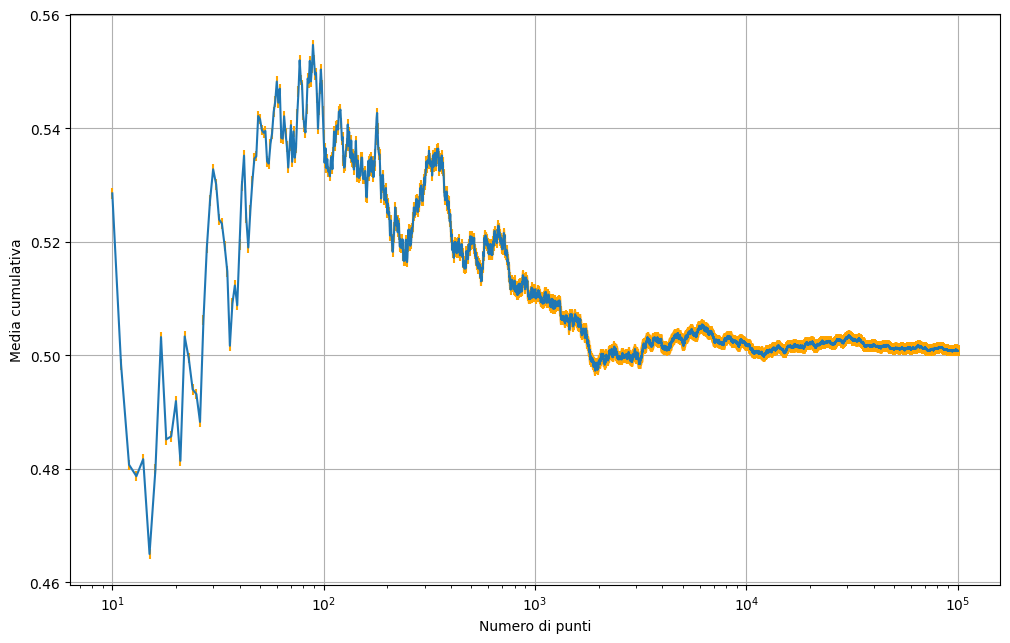

In [5]:
plt.errorbar(
    [x for x in range(10, N)],
    means,
    yerr=1/np.sqrt(12*N),
    ecolor="orange",
    markersize=5
)
plt.xscale("log")
plt.xlabel("Numero di punti")
plt.ylabel("Media cumulativa")
plt.grid()
plt.show()

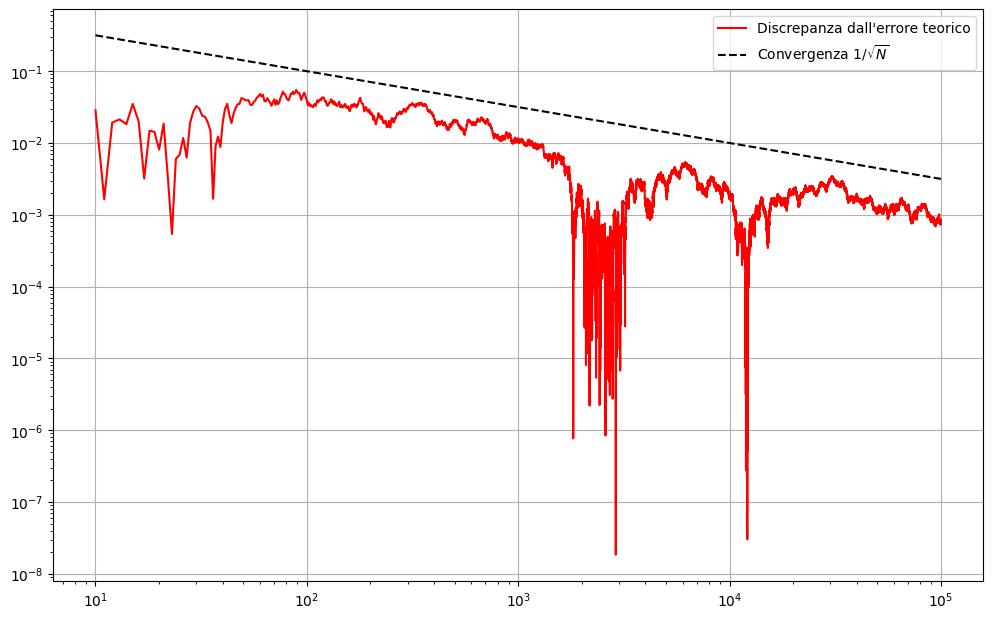

In [7]:
N_th = np.arange(10, len(means)+10)
err_th = 1 / np.sqrt(N_th)
plt.loglog(N_th, np.abs(means-0.5), color="red", label="Discrepanza dall'errore teorico")
plt.plot(N_th, err_th, "--", color="black", label=r"Convergenza $1/\sqrt{N}$")
plt.grid()
plt.legend()
plt.show()

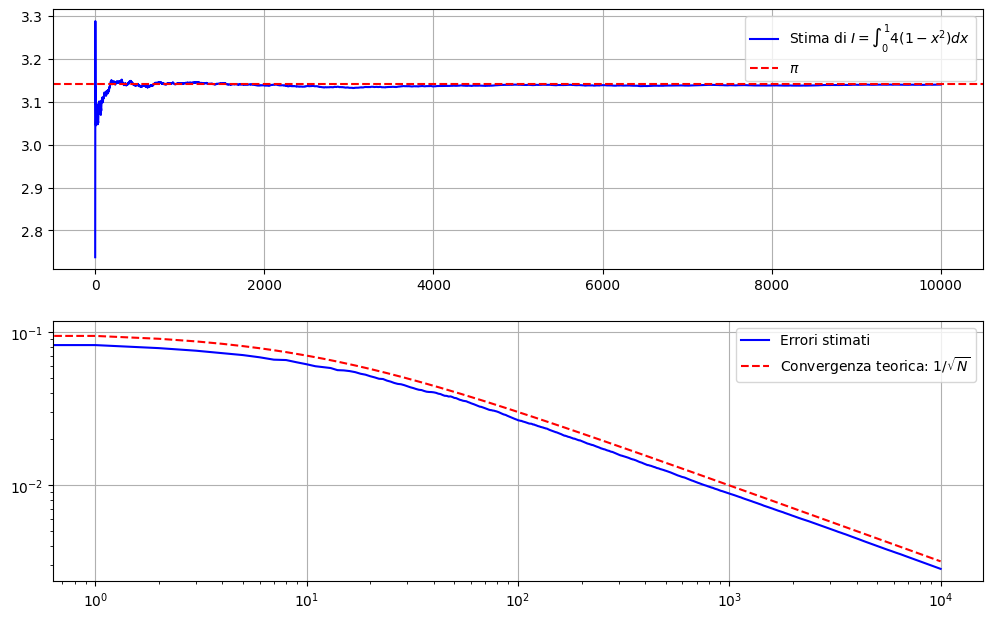

In [8]:
def f(x):
    return 4 * np.sqrt(1 - x**2)

def stimatore(rng: list[float], f: callable) -> float:
    return np.mean(f(rng))

Ns = np.linspace(1, 100_000, 10000).astype(int)
stime = np.zeros(len(Ns))
errs = np.zeros(len(Ns))

for i in range(len(Ns)):
    rng = rngs[:Ns[i]]
    stime[i] = stimatore(rng, f)
    sigma_f = np.std(f(rng))
    errs[i] = sigma_f / np.sqrt(Ns[i])

fig, (ax1, ax2) = plt.subplots(2, 1)
ax1.plot(stime, color="blue", label=r"Stima di $I=\int_{0}^{1}4(1-x^2)dx$")
ax1.axhline(np.pi, ls="--", color="red", label=r"$\pi$")
ax1.grid(True)
ax1.legend()
ax2.plot(errs[10:], color="blue", label="Errori stimati")
ax2.plot(1/np.sqrt(Ns[10:]), "--", color="red", label=r"Convergenza teorica: $1/\sqrt{N}$")
ax2.set_xscale("log")
ax2.set_yscale("log")
ax2.grid(True)
ax2.legend()
plt.show()

In [17]:
rng = np.random.default_rng(seed=42)
def metropolis(lattice, J, T, N, even_mask):
    kb = 1.0
    for s in [even_mask, ~even_mask]:
        neig_sum = np.roll(lattice, shift=1, axis=0) + np.roll(lattice, shift=-1, axis=0) + np.roll(lattice, shift=1, axis=1) + np.roll(lattice, shift=-1, axis=1)
        de = np.zeros_like(lattice)
        de[s] = 2 * J * lattice[s] * neig_sum[s]
        prob = np.exp(-de/(kb*T))
        accept = (de <= 0) | (rng.random((N,N)) < prob)
        lattice[s & accept] *= -1

In [13]:
def total_energy(lattice, L, J):
    neig_sum = np.roll(lattice, shift=1, axis=0) + np.roll(lattice, shift=-1, axis=0) + np.roll(lattice, shift=1, axis=1) + np.roll(lattice, shift=-1, axis=1)
    return -J * np.sum(lattice * neig_sum) / 2

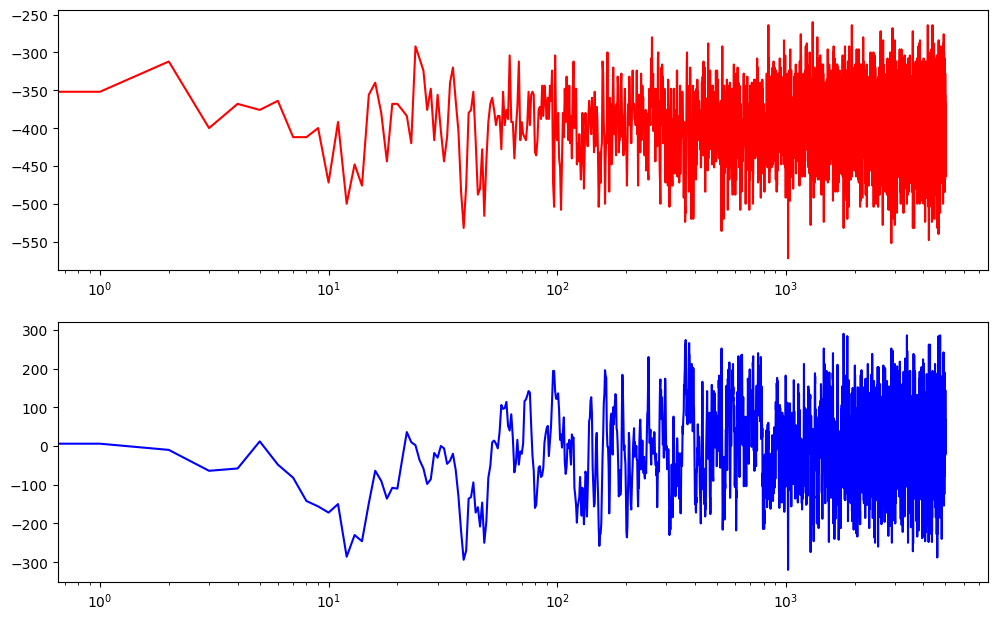

In [27]:
L = 20
J, T = 1.0, 2.669
even_mask = np.zeros((L,L), dtype=bool)
even_mask[::2, ::2] = True # sto considerando le colonne pari e le righe pari
even_mask[1::2, 1::2] = True # sto considerando le colonne dispari e le righe dispari
term_steps = 3000
measure_steps = 5000

lattice = np.random.choice([-1,1], size=(L, L))

# termalizzazione
for step in range(term_steps):
    metropolis(lattice, J, T, L, even_mask)
    metropolis(lattice, J, T, L, even_mask)


energies = np.zeros(measure_steps)
magn = np.zeros(measure_steps)
for step in range(measure_steps):    
    metropolis(lattice, J, T, L, even_mask)
    metropolis(lattice, J, T, L, even_mask)
    energies[step] = total_energy(lattice, L, J)
    magn[step] = np.sum(lattice)

fig, (ax1, ax2) = plt.subplots(2, 1)
ax1.plot(energies, color="red", label=r"Energia a $T=2.0$")
ax1.set_xscale("log")
ax2.plot(magn, color="blue", label=r"Magnetizzazione a $T=2.0$")
ax2.set_xscale("log")
plt.show()

In [28]:
temps = np.array([1.0, 1.5, 2.0, 2.2, 2.3, 2.4, 2.5, 3.0, 4.0])
mean_en = np.zeros_like(temps)
mean_magn = np.zeros_like(temps)
term_steps, measure_steps = 100*L, 300*L


for i in range(len(temps)):
    lattice = np.random.choice([-1,1], size=(L,L))
    
    for _ in range(term_steps):
        metropolis(lattice, J, temps[i], L, even_mask)
        metropolis(lattice, J, T, L, even_mask)

    
    energies = np.zeros(measure_steps)
    magn = np.zeros(measure_steps)
    for step in range(measure_steps):
        metropolis(lattice, J, temps[i], L, even_mask)
        metropolis(lattice, J, T, L, even_mask)

        energies[step] = total_energy(lattice, L, J)
        magn[step] = np.sum(lattice)

    mean_en[i] = np.mean(energies) / (L**2)
    mean_magn[i] = np.mean(np.abs(magn)) / (L**2)

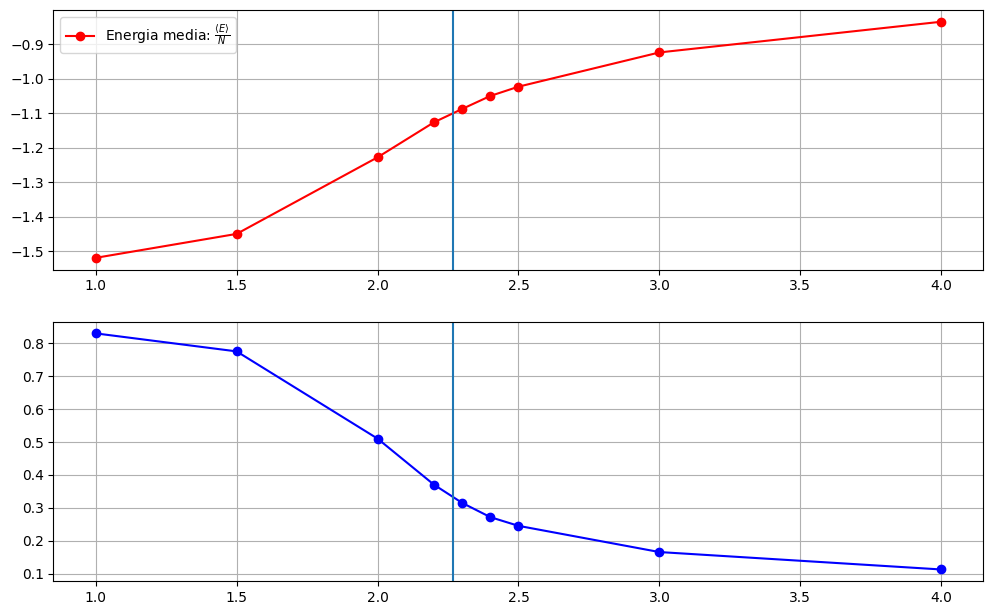

In [30]:
fig, (ax1, ax2) = plt.subplots(2, 1)
ax1.plot(temps, mean_en, "-o", color="red", label=r"Energia media: $\frac{\langle E \rangle}{N}$")
ax1.legend()
ax2.plot(temps, mean_magn, "-o", color="blue", label=r"Magnetizzazione media: $\frac{\langle |M| \rangle}{N}$")
ax1.axvline(2.269)
ax2.axvline(2.269)
ax1.grid()
ax2.grid()
plt.show()

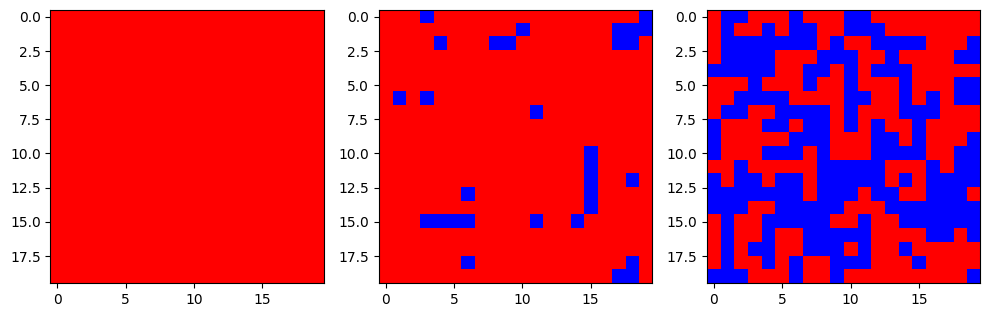

In [29]:
low_lattice = np.random.choice([-1,1], size=(L,L))
crit_lattice = np.random.choice([-1,1], size=(L,L))
high_lattice = np.random.choice([-1,1], size=(L,L))
CMAP = ListedColormap(["red", "blue"])
term_steps, measure_steps = 7500, 2000

for _ in range(term_steps):
    metropolis(low_lattice, J, 1.0, L, even_mask)
    metropolis(low_lattice, J, 1.0, L, even_mask)
    metropolis(crit_lattice, J, 2.269, L, even_mask)
    metropolis(crit_lattice, J, 2.269, L, even_mask)
    metropolis(high_lattice, J, 4.0, L, even_mask)
    metropolis(high_lattice, J, 4.0, L, even_mask)

for _ in range(measure_steps):
    metropolis(low_lattice, J, 1.0, L, even_mask)
    metropolis(low_lattice, J, 1.0, L, even_mask)
    metropolis(crit_lattice, J, 2.269, L, even_mask)
    metropolis(crit_lattice, J, 2.269, L, even_mask)
    metropolis(high_lattice, J, 4.0, L, even_mask)
    metropolis(high_lattice, J, 4.0, L, even_mask)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3)
ax1.imshow(low_lattice, cmap=CMAP)
ax2.imshow(crit_lattice, cmap=CMAP)
ax3.imshow(high_lattice, cmap=CMAP)
plt.show()